In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv")

In [5]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [16]:
vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.8
)
X = vectorizer.fit_transform(df["phrases_lemm"])

In [18]:
kmeans= KMeans(n_clusters=10, 
               random_state=42,
               n_init=10)

df["cluster"] = kmeans.fit_predict(X)

In [19]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,5
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,5
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,9
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,5
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,9


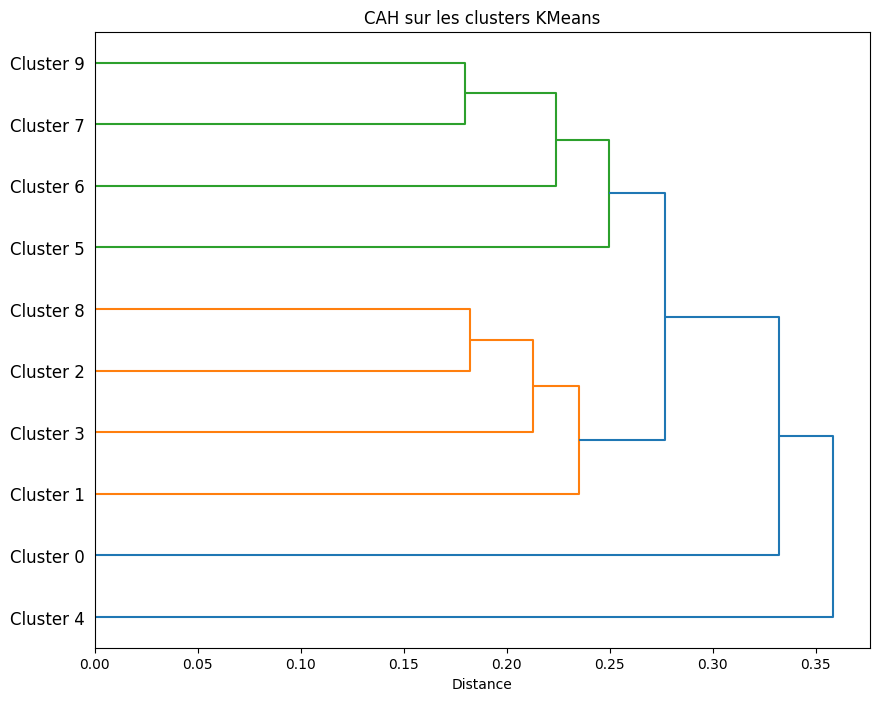

In [ ]:
centres = kmeans.cluster_centers_
Z = linkage(centres, method="ward")

plt.figure(figsize=(10, 8))
dendrogram(
    Z,
    labels=[f"Cluster {i}" for i in range(kmeans.n_clusters)],
    orientation="right"
)

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()